# Hertfordshire KS4 Policy Performance Analysis

This notebook builds a four-year KS4 analysis panel for Hertfordshire schools using data published by the government (https://www.gov.uk/school-performance-tables).

Scope:
- Academic years: `2021-2022`, `2022-2023`, `2023-2024`, `2024-2025`
- Outcomes: Progress 8, Attainment 8, and English/maths grade 5+ measures
- Context: deprivation, attendance, SEND, school type, admissions policy, roll size, and gender

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.2f}".format)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
YEARS = ["2021-2022", "2022-2023", "2023-2024", "2024-2025"]


## Raw File Exploration

Before defining the analysis columns and filters, inspect the raw yearly files to see available columns, row counts, valid school rows, and census `SCHOOLTYPE` groups.

In [ ]:
RAW_FILES = {
    "ks4": "919_ks4final.csv",
    "census": "919_census.csv",
    "absence": "919_abs.csv",
}
CANDIDATE_ANALYSIS_COLUMNS = [
    "P8MEA", "P8MEAENG", "P8MEAMAT", "P8MEAEBAC", "P8MEAOPEN",
    "ATT8SCR", "ATT8SCRENG", "ATT8SCRMAT", "ATT8SCREBAC", "ATT8SCROPEN",
    "PTL2BASICS_95", "PNUMFSMEVER", "PERCTOT", "PPERSABS10",
    "PSEN_ALL4", "SCHOOLTYPE", "ADMPOL", "NOR", "NORG", "NORB",
    "PNORG", "PNORB", "EGENDER",
]

raw_file_rows = []
raw_column_rows = []
raw_schooltype_rows = []

for year in YEARS:
    year_dir = DATA_DIR / year
    for source_name in RAW_FILES:
        file_name = RAW_FILES[source_name]
        path = year_dir / file_name
        if not path.exists():
            raw_file_rows.append({"academic_year": year, "file": file_name, "exists": False, "rows": 0, "columns": 0, "valid_urn_rows": pd.NA})
            continue

        data = pd.read_csv(path, dtype="string", low_memory=False)
        urn = pd.to_numeric(data["URN"], errors="coerce") if "URN" in data.columns else pd.Series(pd.NA, index=data.index)
        raw_file_rows.append(
            {
                "academic_year": year,
                "file": file_name,
                "exists": True,
                "rows": len(data),
                "columns": len(data.columns),
                "valid_urn_rows": int(urn.notna().sum()),
            }
        )

        for column in CANDIDATE_ANALYSIS_COLUMNS:
            if column in data.columns:
                raw_column_rows.append({"academic_year": year, "file": file_name, "column": column})

    census_path = year_dir / RAW_FILES["census"]
    if census_path.exists():
        census = pd.read_csv(census_path, dtype="string", low_memory=False)
        census["URN_NUM"] = pd.to_numeric(census["URN"], errors="coerce")
        census = census[census["URN_NUM"].notna()].drop_duplicates(subset="URN_NUM")
        for schooltype, count in census["SCHOOLTYPE"].fillna("<missing>").value_counts(dropna=False).items():
            raw_schooltype_rows.append({"academic_year": year, "SCHOOLTYPE": schooltype, "census_rows": int(count)})

raw_file_summary = pd.DataFrame(raw_file_rows)
raw_column_presence = (
    pd.DataFrame(raw_column_rows)
    .assign(present=True)
    .pivot_table(index=["column", "file"], columns="academic_year", values="present", aggfunc="any", fill_value=False)
    .reset_index()
)
raw_schooltype_counts = pd.DataFrame(raw_schooltype_rows).sort_values(["academic_year", "census_rows"], ascending=[True, False])
raw_schooltype_group_counts = raw_schooltype_counts.groupby("academic_year").size().rename("census_schooltype_groups")

display(raw_file_summary)
display(raw_column_presence)
display(raw_schooltype_group_counts)
display(raw_schooltype_counts)


## Analysis Definitions

Based on the raw file exploration, define the final school-type filter, selected columns, and cleaning codes used by the loader.

In [ ]:
ALLOWED_SCHOOLTYPES = ["State-funded secondary"]
EXPECTED_KS4_ROWS = {}

OUTCOME_COLUMNS = [
    "P8MEA",
    "P8MEAENG",
    "P8MEAMAT",
    "P8MEAEBAC",
    "P8MEAOPEN",
    "ATT8SCR",
    "ATT8SCRENG",
    "ATT8SCRMAT",
    "ATT8SCREBAC",
    "ATT8SCROPEN",
    "PTL2BASICS_95",
]

CONTEXT_COLUMNS = [
    "PNUMFSMEVER",
    "PERCTOT",
    "PPERSABS10",
    "PSEN_ALL4",
    "SCHOOLTYPE",
    "ADMPOL",
    "NOR",
    "NORG",
    "NORB",
    "PNORG",
    "PNORB",
    "EGENDER",
]

IDENTIFIER_COLUMNS = ["academic_year", "URN", "SCHNAME"]
ANALYSIS_COLUMNS = IDENTIFIER_COLUMNS + OUTCOME_COLUMNS + CONTEXT_COLUMNS
NUMERIC_COLUMNS = OUTCOME_COLUMNS + ["PNUMFSMEVER", "PERCTOT", "PPERSABS10", "PSEN_ALL4", "NOR", "NORG", "NORB", "PNORG", "PNORB"]

MISSING_CODES = {
    "",
    "-",
    "NA",
    "N/A",
    "NAN",
    "NE",
    "NEW",
    "NP",
    "SUPP",
    "LOWCOV",
    "SP",
    "X",
}


In [ ]:
def clean_numeric(series: pd.Series) -> pd.Series:
    """Convert school performance strings, percentages, and suppression codes to numeric values."""
    text = series.astype("string").str.strip()
    text = text.str.replace(",", "", regex=False).str.replace("%", "", regex=False)
    text = text.mask(text.str.upper().isin(MISSING_CODES))
    return pd.to_numeric(text, errors="coerce")


def normalise_urn(series: pd.Series) -> pd.Series:
    """Normalise URNs that sometimes arrive as strings like '117600.0'."""
    return pd.to_numeric(series, errors="coerce").astype("Int64")


def read_selected_csv(path: Path, columns: list[str]) -> pd.DataFrame:
    """Read only requested columns and add missing requested columns as NA."""
    header = pd.read_csv(path, nrows=0).columns.tolist()
    present = [column for column in columns if column in header]
    data = pd.read_csv(path, usecols=present, dtype="string", low_memory=False)
    for column in columns:
        if column not in data.columns:
            data[column] = pd.NA
    return data[columns]


def load_year(year: str) -> pd.DataFrame:
    year_dir = DATA_DIR / year
    ks4_path = year_dir / RAW_FILES["ks4"]
    census_path = year_dir / RAW_FILES["census"]
    absence_path = year_dir / RAW_FILES["absence"]

    ks4_columns = ["URN", "SCHNAME", "EGENDER", "ADMPOL", "PSEN_ALL4"] + OUTCOME_COLUMNS
    census_columns = ["URN", "SCHOOLTYPE", "NOR", "NORG", "NORB", "PNORG", "PNORB", "PNUMFSMEVER"]
    absence_columns = ["URN", "PERCTOT", "PPERSABS10"]

    ks4 = read_selected_csv(ks4_path, ks4_columns)
    ks4["academic_year"] = year
    ks4["URN"] = normalise_urn(ks4["URN"])
    ks4 = ks4[ks4["URN"].notna()].copy()
    census = read_selected_csv(census_path, census_columns)
    census["URN"] = normalise_urn(census["URN"])
    census = census[census["URN"].notna()].drop_duplicates(subset="URN")

    panel = ks4.merge(census, on="URN", how="left", validate="many_to_one")
    # Keep only the school types selected for this analysis before building the panel.
    panel = panel[panel["SCHOOLTYPE"].isin(ALLOWED_SCHOOLTYPES)].copy()

    if absence_path.exists():
        absence = read_selected_csv(absence_path, absence_columns)
        absence["URN"] = normalise_urn(absence["URN"])
        absence = absence[absence["URN"].notna()].drop_duplicates(subset="URN")
        panel = panel.merge(absence, on="URN", how="left", validate="many_to_one")
    else:
        panel["PERCTOT"] = pd.NA
        panel["PPERSABS10"] = pd.NA

    for column in NUMERIC_COLUMNS:
        panel[column] = clean_numeric(panel[column])

    return panel[ANALYSIS_COLUMNS]


def build_panel(years: list[str] = YEARS) -> pd.DataFrame:
    return pd.concat([load_year(year) for year in years], ignore_index=True)

## Preliminary Source Audit

This section derives the row-count checks, inspects the census `SCHOOLTYPE` groups, and identifies which groups are retained for the analysis panel.

In [ ]:
audit_rows = []
schooltype_rows = []
column_availability_rows = []

source_columns = {
    "ks4": ["URN", "SCHNAME", "EGENDER", "ADMPOL", "PSEN_ALL4"] + OUTCOME_COLUMNS,
    "census": ["URN", "SCHOOLTYPE", "NOR", "NORG", "NORB", "PNORG", "PNORB", "PNUMFSMEVER"],
    "absence": ["URN", "PERCTOT", "PPERSABS10"],
}

for year in YEARS:
    year_dir = DATA_DIR / year
    source_paths = {source_name: year_dir / file_name for source_name, file_name in RAW_FILES.items()}
    ks4_path = source_paths["ks4"]
    census_path = source_paths["census"]
    absence_path = source_paths["absence"]

    ks4_raw = pd.read_csv(ks4_path, dtype="string", low_memory=False)
    ks4_urn = normalise_urn(ks4_raw["URN"])
    valid_ks4 = ks4_raw.assign(URN_NUM=ks4_urn).loc[ks4_urn.notna()].copy()

    audit_rows.append(
        {
            "academic_year": year,
            "raw_ks4_rows": len(ks4_raw),
            "valid_urn_rows": int(ks4_urn.notna().sum()),
            "invalid_urn_rows": int(ks4_urn.isna().sum()),
            "unique_school_urns": int(ks4_urn.dropna().nunique()),
        }
    )

    census_raw = pd.read_csv(census_path, dtype="string", low_memory=False)
    census = census_raw.assign(URN_NUM=normalise_urn(census_raw["URN"]))
    census = census[census["URN_NUM"].notna()].drop_duplicates(subset="URN_NUM")
    schooltype_join = valid_ks4[["URN_NUM"]].merge(
        census[["URN_NUM", "SCHOOLTYPE"]], on="URN_NUM", how="left", validate="many_to_one"
    )
    audit_rows[-1]["retained_schooltype_rows"] = int(schooltype_join["SCHOOLTYPE"].isin(ALLOWED_SCHOOLTYPES).sum())
    schooltype_counts = schooltype_join["SCHOOLTYPE"].fillna("<missing>").value_counts(dropna=False)
    for schooltype, count in schooltype_counts.items():
        schooltype_rows.append(
            {
                "academic_year": year,
                "SCHOOLTYPE": schooltype,
                "schools": int(count),
                "kept_in_analysis": schooltype in ALLOWED_SCHOOLTYPES,
                "share_pct": round(count / len(valid_ks4) * 100, 1),
            }
        )

    for source_name, expected_columns in source_columns.items():
        path = source_paths[source_name]
        if path.exists():
            columns = set(pd.read_csv(path, nrows=0).columns)
            missing = [column for column in expected_columns if column not in columns]
            present = len(expected_columns) - len(missing)
        else:
            missing = expected_columns
            present = 0
        column_availability_rows.append(
            {
                "academic_year": year,
                "source": source_name,
                "expected_columns": len(expected_columns),
                "present_columns": present,
                "missing_columns": ", ".join(missing) if missing else "",
            }
        )

source_audit = pd.DataFrame(audit_rows)
schooltype_counts = pd.DataFrame(schooltype_rows).sort_values(["academic_year", "schools"], ascending=[True, False])
schooltype_group_counts = schooltype_counts.groupby("academic_year").size().rename("all_discovered_schooltype_groups")
retained_schooltype_counts = schooltype_counts[schooltype_counts["kept_in_analysis"]].copy()
retained_schooltype_group_counts = retained_schooltype_counts.groupby("academic_year").size().rename("retained_schooltype_groups")
column_availability = pd.DataFrame(column_availability_rows)
EXPECTED_KS4_ROWS = source_audit.set_index("academic_year")["retained_schooltype_rows"].to_dict()

display(source_audit)
display(column_availability)
display(schooltype_group_counts)
display(retained_schooltype_group_counts)
display(retained_schooltype_counts)

In [ ]:
panel = build_panel()

display(panel.head())
display(panel.tail())
print(f"Rows: {len(panel):,}")
print(f"Columns: {len(panel.columns):,}")

## Data Checks

These checks confirm that the notebook is using the intended school universe and source mapping.

In [ ]:
assert EXPECTED_KS4_ROWS, "Run the Preliminary Source Audit section before the data checks."
actual_counts = panel.groupby("academic_year").size().to_dict()
assert actual_counts == EXPECTED_KS4_ROWS, actual_counts

for column in ["SCHOOLTYPE", "NOR", "NORG", "NORB", "PNORG", "PNORB", "PNUMFSMEVER"]:
    assert panel.groupby("academic_year")[column].apply(lambda values: values.notna().any()).all(), column

assert set(panel["SCHOOLTYPE"].dropna().unique()).issubset(set(ALLOWED_SCHOOLTYPES))

assert "EGENDER" in panel.columns
assert "GENDER" not in panel.columns

assert panel.loc[panel["academic_year"] == "2024-2025", ["PERCTOT", "PPERSABS10"]].isna().all().all()
assert panel.loc[panel["academic_year"] == "2024-2025", ["P8MEA", "P8MEAENG", "P8MEAMAT", "P8MEAEBAC", "P8MEAOPEN"]].isna().all().all()

print("All checks passed.")
display(pd.Series(actual_counts, name="ks4_rows"))

## Coverage and Missingness

In [ ]:
non_null_counts = panel.groupby("academic_year")[OUTCOME_COLUMNS + CONTEXT_COLUMNS].count().T
missing_rates = panel.groupby("academic_year")[OUTCOME_COLUMNS + CONTEXT_COLUMNS].apply(lambda frame: frame.isna().mean() * 100).T

display(non_null_counts)
display(missing_rates.round(1))

## Outcome Trends

In [ ]:
progress8_columns = ["P8MEA", "P8MEAENG", "P8MEAMAT", "P8MEAEBAC", "P8MEAOPEN"]
attainment8_columns = ["ATT8SCR", "ATT8SCRENG", "ATT8SCRMAT", "ATT8SCREBAC", "ATT8SCROPEN"]

progress8_trends = panel.groupby("academic_year")[progress8_columns].mean()
attainment_trends = panel.groupby("academic_year")[attainment8_columns + ["PTL2BASICS_95"]].mean()

display(progress8_trends.round(2))
display(attainment_trends.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
progress8_trends.plot(marker="o", ax=axes[0])
axes[0].axhline(0, color="black", linewidth=0.8, alpha=0.5)
axes[0].set_title("Mean Progress 8 Measures")
axes[0].set_xlabel("Academic year")
axes[0].set_ylabel("Mean score")
axes[0].tick_params(axis="x", rotation=35)

attainment_trends.plot(marker="o", ax=axes[1])
axes[1].set_title("Mean Attainment 8 and Grade 5+ Measures")
axes[1].set_xlabel("Academic year")
axes[1].set_ylabel("Mean value")
axes[1].tick_params(axis="x", rotation=35)

for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend(fontsize=8)

plt.tight_layout()

## Context Relationships

The following charts use only `State-funded secondary` schools. They are descriptive associations and do not estimate causal effects.

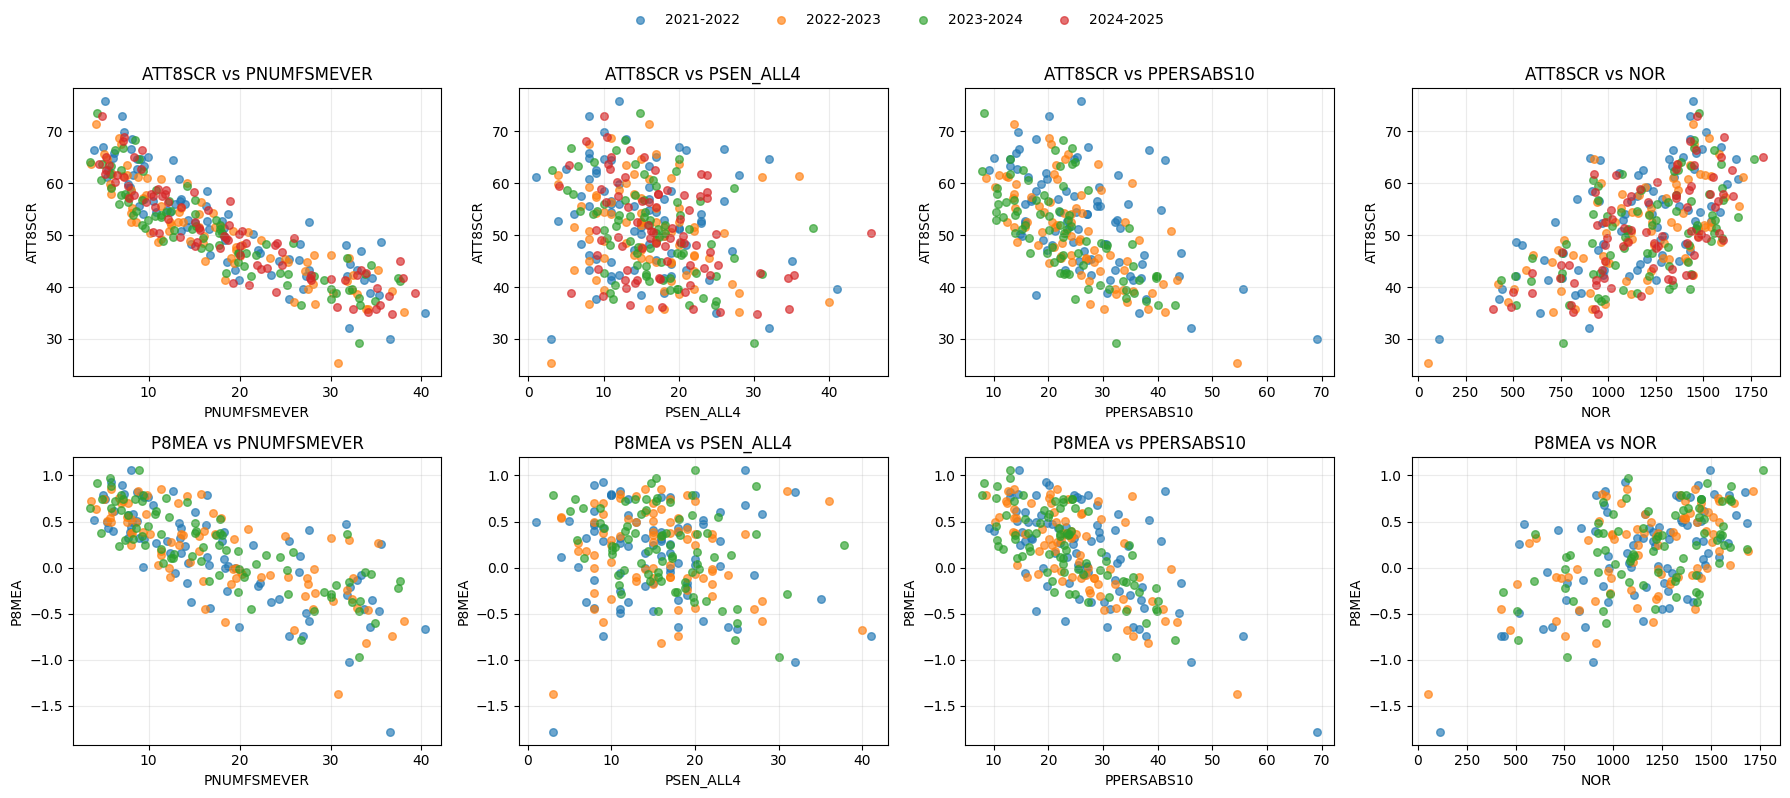

In [65]:
state_funded_panel = panel[panel["SCHOOLTYPE"].eq("State-funded secondary")].copy()

def scatter_by_year(x: str, y: str, ax: plt.Axes) -> None:
    valid = state_funded_panel.dropna(subset=[x, y])
    for year, group in valid.groupby("academic_year"):
        ax.scatter(group[x], group[y], label=year, alpha=0.65, s=30)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{y} vs {x}")
    ax.grid(alpha=0.25)


scatter_pairs = [
    ("PNUMFSMEVER", "ATT8SCR"),
    ("PSEN_ALL4", "ATT8SCR"),
    ("PPERSABS10", "ATT8SCR"),
    ("NOR", "ATT8SCR"),
    ("PNUMFSMEVER", "P8MEA"),
    ("PSEN_ALL4", "P8MEA"),
    ("PPERSABS10", "P8MEA"),
    ("NOR", "P8MEA"),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for axis, (x, y) in zip(axes.ravel(), scatter_pairs):
    scatter_by_year(x, y, axis)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(YEARS), frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.94])

## Multiple Regression: Predicting Attainment 8

This section predicts `ATT8SCR` using context variables for state-funded secondary schools only. It is descriptive and predictive, not causal.

`PERCTOT` and `PPERSABS10` are not available for `2024-2025`, so the attendance model uses years with attendance data only. `NORB`, `NORG`, and `PNORB` are not included as separate predictors because they are redundant with `NOR` and `PNORG`.

In [ ]:
REGRESSION_TARGET = "ATT8SCR"
REGRESSION_NUMERIC_FEATURES = ["PNUMFSMEVER", "PERCTOT", "PPERSABS10", "PSEN_ALL4", "NOR", "PNORG"]
REGRESSION_CATEGORICAL_FEATURES = ["academic_year", "EGENDER", "ADMPOL"]

regression_columns = [REGRESSION_TARGET] + REGRESSION_NUMERIC_FEATURES + REGRESSION_CATEGORICAL_FEATURES + ["URN", "SCHNAME"]
regression_data = panel[regression_columns].copy()
regression_data[REGRESSION_CATEGORICAL_FEATURES] = regression_data[REGRESSION_CATEGORICAL_FEATURES].fillna("Missing")
regression_data = regression_data.dropna(subset=[REGRESSION_TARGET] + REGRESSION_NUMERIC_FEATURES).copy()

X_numeric_raw = regression_data[REGRESSION_NUMERIC_FEATURES].astype(float)
feature_means = X_numeric_raw.mean()
feature_stds = X_numeric_raw.std(ddof=0).replace(0, 1)
X_numeric = (X_numeric_raw - feature_means) / feature_stds
X_categorical = pd.get_dummies(regression_data[REGRESSION_CATEGORICAL_FEATURES], drop_first=True, dtype=float)
X = pd.concat([X_numeric, X_categorical], axis=1)
X.insert(0, "Intercept", 1.0)
y = regression_data[REGRESSION_TARGET].astype(float)

beta, residuals, rank, singular_values = np.linalg.lstsq(X.to_numpy(dtype=float), y.to_numpy(dtype=float), rcond=None)
predicted = X.to_numpy(dtype=float) @ beta
errors = y.to_numpy(dtype=float) - predicted

n_obs = len(y)
n_features = X.shape[1] - 1
sse = float(np.sum(errors**2))
sst = float(np.sum((y - y.mean()) ** 2))
r2 = 1 - sse / sst
adj_r2 = 1 - (1 - r2) * (n_obs - 1) / (n_obs - n_features - 1)
rmse = float(np.sqrt(np.mean(errors**2)))
mae = float(np.mean(np.abs(errors)))

regression_summary = pd.DataFrame(
    {
        "metric": ["observations", "features", "rank", "r2", "adjusted_r2", "rmse", "mae"],
        "value": [n_obs, n_features, rank, r2, adj_r2, rmse, mae],
    }
)

coefficient_table = (
    pd.DataFrame({"feature": X.columns, "coefficient": beta})
    .assign(abs_coefficient=lambda frame: frame["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
    .drop(columns="abs_coefficient")
)

prediction_results = regression_data[["academic_year", "URN", "SCHNAME", REGRESSION_TARGET]].copy()
prediction_results["predicted_ATT8SCR"] = predicted
prediction_results["residual"] = prediction_results[REGRESSION_TARGET] - prediction_results["predicted_ATT8SCR"]

display(regression_data.groupby("academic_year").size().rename("regression_rows"))
display(regression_summary.round(3))
display(coefficient_table.round(3))
display(prediction_results.sort_values("residual", key=lambda s: s.abs(), ascending=False).head(15).round(2))

fig, axis = plt.subplots(figsize=(6.5, 5.5))
axis.scatter(prediction_results[REGRESSION_TARGET], prediction_results["predicted_ATT8SCR"], alpha=0.7)
line_min = min(prediction_results[REGRESSION_TARGET].min(), prediction_results["predicted_ATT8SCR"].min())
line_max = max(prediction_results[REGRESSION_TARGET].max(), prediction_results["predicted_ATT8SCR"].max())
axis.plot([line_min, line_max], [line_min, line_max], color="black", linewidth=1, alpha=0.6)
axis.set_title("Actual vs Predicted ATT8SCR")
axis.set_xlabel("Actual ATT8SCR")
axis.set_ylabel("Predicted ATT8SCR")
axis.grid(alpha=0.25)
plt.tight_layout()

## Grouped Summaries

In [ ]:
def grouped_summary(group_col: str) -> pd.DataFrame:
    return (
        panel.groupby(["academic_year", group_col], dropna=False)
        .agg(
            schools=("URN", "count"),
            mean_p8=("P8MEA", "mean"),
            mean_att8=("ATT8SCR", "mean"),
            mean_grade5=("PTL2BASICS_95", "mean"),
            mean_fsm=("PNUMFSMEVER", "mean"),
            mean_persistent_absence=("PPERSABS10", "mean"),
            mean_send=("PSEN_ALL4", "mean"),
            mean_nor=("NOR", "mean"),
            mean_norg=("NORG", "mean"),
            mean_norb=("NORB", "mean"),
            mean_pnorg=("PNORG", "mean"),
            mean_pnorb=("PNORB", "mean"),
        )
        .reset_index()
        .sort_values(["academic_year", "schools"], ascending=[True, False])
    )


for group_column in ["SCHOOLTYPE", "ADMPOL", "EGENDER"]:
    print(f"\n{group_column}")
    display(grouped_summary(group_column).round(2))

## Ranked School Tables

In [ ]:
ranking_columns = [
    "academic_year",
    "URN",
    "SCHNAME",
    "SCHOOLTYPE",
    "ADMPOL",
    "EGENDER",
    "P8MEA",
    "ATT8SCR",
    "PTL2BASICS_95",
    "PNUMFSMEVER",
    "PPERSABS10",
    "PSEN_ALL4",
    "NOR",
    "NORG",
    "NORB",
    "PNORG",
    "PNORB",
]

high_deprivation = (
    panel.dropna(subset=["PNUMFSMEVER"])
    .sort_values(["academic_year", "PNUMFSMEVER", "ATT8SCR"], ascending=[True, False, False])
    .groupby("academic_year")
    .head(10)[ranking_columns]
)

highest_attainment = (
    panel.dropna(subset=["ATT8SCR"])
    .sort_values(["academic_year", "ATT8SCR"], ascending=[True, False])
    .groupby("academic_year")
    .head(10)[ranking_columns]
)

display(high_deprivation.round(2))
display(highest_attainment.round(2))

## Policy Findings Evidence

The tables below collect the main evidence used for the final policy summary.

In [ ]:
policy_outcome_summary = (
    panel.groupby("academic_year")
    .agg(
        schools=("URN", "count"),
        mean_att8=("ATT8SCR", "mean"),
        mean_grade5=("PTL2BASICS_95", "mean"),
        mean_p8=("P8MEA", "mean"),
        mean_fsm6=("PNUMFSMEVER", "mean"),
        mean_persistent_absence=("PPERSABS10", "mean"),
        mean_send=("PSEN_ALL4", "mean"),
        mean_nor=("NOR", "mean"),
    )
    .round(2)
)

policy_correlation_summary = (
    panel.loc[panel["academic_year"].ne("2024-2025"), ["ATT8SCR", "PNUMFSMEVER", "PERCTOT", "PPERSABS10", "PSEN_ALL4", "NOR", "PNORG"]]
    .corr(numeric_only=True)["ATT8SCR"]
    .drop("ATT8SCR")
    .sort_values()
    .rename("correlation_with_ATT8SCR")
    .round(3)
)

policy_regression_coefficients = (
    coefficient_table[coefficient_table["feature"].isin(["PNUMFSMEVER", "PERCTOT", "PPERSABS10", "PSEN_ALL4", "NOR", "PNORG"])]
    .set_index("feature")["coefficient"]
    .round(3)
)

display(policy_outcome_summary)
display(policy_correlation_summary)
display(policy_regression_coefficients)


## Policy Summary

This notebook now analyses **state-funded secondary schools only**, so the findings are about the local mainstream secondary accountability system rather than independent or special-school provision.

**Main findings**

- Attainment is broadly flat after a post-2021-2022 drop. Mean `ATT8SCR` falls from about **52.9** in `2021-2022` to about **50.6-50.8** from `2022-2023` onward. The grade 5+ English/maths measure also falls from about **56.3%** to about **52.8-53.8%**.
- Progress 8 is positive and slightly improving where populated: mean `P8MEA` rises from about **0.15** in `2021-2022` to **0.21** in `2023-2024`. `2024-2025` should not be used for Progress 8 conclusions because the selected Progress 8 columns are not populated.
- Deprivation is the strongest policy signal. `PNUMFSMEVER` has a strong negative association with `ATT8SCR` in the available years, and it is the largest contextual coefficient in the multiple regression. This supports prioritising disadvantaged-pupil attainment and school-level deprivation as the main equity lens.
- Attendance is also policy-relevant. Persistent absence improves from about **26.5%** in `2021-2022` to **23.4%** in `2023-2024`, but absence remains strongly negatively associated with `ATT8SCR`. `2024-2025` has no absence file, so attendance findings stop at `2023-2024`.
- SEND need is rising: mean `PSEN_ALL4` increases from about **15.5%** to **17.6%** across the panel. Its simple relationship with attainment is weaker than deprivation and attendance, and the regression suggests much of the SEND signal overlaps with other context variables.
- Smaller `ADMPOL == NR` schools have lower average attainment and higher deprivation/absence in these data, but there are only about six such schools per year. Treat this as a flag for follow-up rather than a standalone policy conclusion.

**Policy implications**

- Focus intervention analysis on high-`PNUMFSMEVER` schools first, then inspect attendance as a likely operational lever.
- Use state-funded secondary schools as the benchmark group for DfE accountability metrics; independent-school accountability values are not comparable and have been excluded from the panel.
- Report `2024-2025` attainment outcomes, but keep Progress 8 and attendance trend claims limited to years where those fields are populated.
- Treat the regression as descriptive evidence for prioritisation, not causal proof. The model explains a large share of variation, but the predictors are correlated and the school-year panel is small.
